# TP — Régression Linéaire sur le Gaming Behavior Dataset
## Méthodologie : CRISP-DM


> **Dataset :** [Online Gaming Behavior Insight — Kaggle](https://www.kaggle.com/datasets/wasiqaliyasir/online-gaming-behavior-insight)  
> **Objectif :** Appliquer la régression linéaire simple et multiple sur des données réelles en suivant les 6 phases de CRISP-DM.

---

##  Rappel : Les 6 phases de CRISP-DM

| Phase | Nom | Ce qu'on fait |
|-------|-----|---------------|
| 1 | **Business Understanding** | Définir le problème métier |
| 2 | **Data Understanding** | Explorer et comprendre les données |
| 3 | **Data Preparation** | Nettoyer et transformer les données |
| 4 | **Modeling** | Construire le(s) modèle(s) de régression |
| 5 | **Evaluation** | Mesurer la qualité du modèle |
| 6 | **Deployment** | Interpréter et communiquer les résultats |

---

## 0. Installation & Imports

Importez toutes les librairies nécessaires pour ce TP.  
Vous aurez besoin de : `pandas`, `numpy`, `matplotlib`, `seaborn`, et des modules de `sklearn`.

In [25]:
# === Imports ===
# TODO : Importez pandas, numpy, matplotlib.pyplot, seaborn
# TODO : importez LinearRegression (module: sklearn.linear)
# TODO : importez train_test_split (module :sklearn.model_selection )
# TODO : importez mean_absolute_error, mean_squared_error, r2_score (les metrics)
# TODO : importez LabelEncoder et/ou OneHotEncoder

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

import warnings
warnings.filterwarnings('ignore')

# Configuration globale des graphiques
# TODO : Fixez le style seaborn et la taille de figure par défaut (ex: (10, 6))
sns.set()
plt.rcParams['figure.figsize'] = (10, 6)

---
## Phase 1 — Business Understanding

### Contexte

Vous êtes data analyst pour une plateforme de jeux en ligne.  
La direction veut mieux comprendre **ce qui influence le temps de jeu hebdomadaire** (`PlayTimeHours`) des joueurs.


### Objectif
Aider la plateforme à identifier les leviers actionnables pour augmenter le temps de jeu des joueurs (rétention, monétisation, personnalisation des recommandations).

### Questions métier à résoudre

1. Le nombre de sessions par semaine (`SessionsPerWeek`) prédit-il significativement le temps de jeu total ?
2. En combinant plusieurs variables (sessions, durée, achievements, niveau), peut-on bâtir un modèle prédictif fiable ?
3. Les variables catégorielles (genre, type de jeu, localisation) ont-elles un impact mesurable ?

### Traduction en problème ML

| Élément | Valeur |
|---------|--------|
| **Type de problème** | Régression (prédiction d'une valeur continue) |
| **Variable cible Y** | `PlayTimeHours` |
| **Variables candidates X** | `SessionsPerWeek`, `AvgSessionDurationMinutes`, `PlayerLevel`, `AchievementsUnlocked`, + catégorielles |
| **Métrique principale** | R² ajusté + RMSE |

---

> **À compléter :** Reformulez la question métier que vous allez résoudre avec la régression linéaire.

**Votre réponse ici :**

_« ... »_

---
## Phase 2 — Data Understanding

### 2.1 Chargement des données

Chargez le fichier CSV téléchargé depuis Kaggle.  
Adaptez le chemin selon votre environnement (Colab, local, etc.).



In [26]:
# TODO : Chargez le dataset avec pandas
path = "/content/drive/MyDrive/EPL/online_gaming_behavior_insights.csv"
# df = pd.read_csv(path)
df = pd.read_csv(path)

# TODO : Affichez les 5 premières lignes
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2.2 Structure du dataset

Commencez par comprendre la **forme** et les **types** de vos données.  

In [28]:
# TODO : Affichez le nombre de lignes et de colonnes
print(df.shape)
# TODO : Affichez les types de chaque colonne (.dtypes ou .info())
print(df.dtypes)
# TODO : Listez les colonnes numériques vs catégorielles
# Indice : df.select_dtypes(include='number') / df.select_dtypes(include='object')
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

print(f"{len(num_cols)} Colonnes numériques : {num_cols}")
print(f"{len(cat_cols)} Colonnes catégorielles : {cat_cols}")

(40034, 13)
PlayerID                       int64
Age                            int64
Gender                        object
Location                      object
GameGenre                     object
PlayTimeHours                float64
InGamePurchases                int64
GameDifficulty                object
SessionsPerWeek                int64
AvgSessionDurationMinutes      int64
PlayerLevel                    int64
AchievementsUnlocked           int64
EngagementLevel               object
dtype: object
8 Colonnes numériques : Index(['PlayerID', 'Age', 'PlayTimeHours', 'InGamePurchases',
       'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel',
       'AchievementsUnlocked'],
      dtype='object')
5 Colonnes catégorielles : Index(['Gender', 'Location', 'GameGenre', 'GameDifficulty', 'EngagementLevel'], dtype='object')


<Axes: xlabel='EngagementLevel', ylabel='PlayTimeHours'>

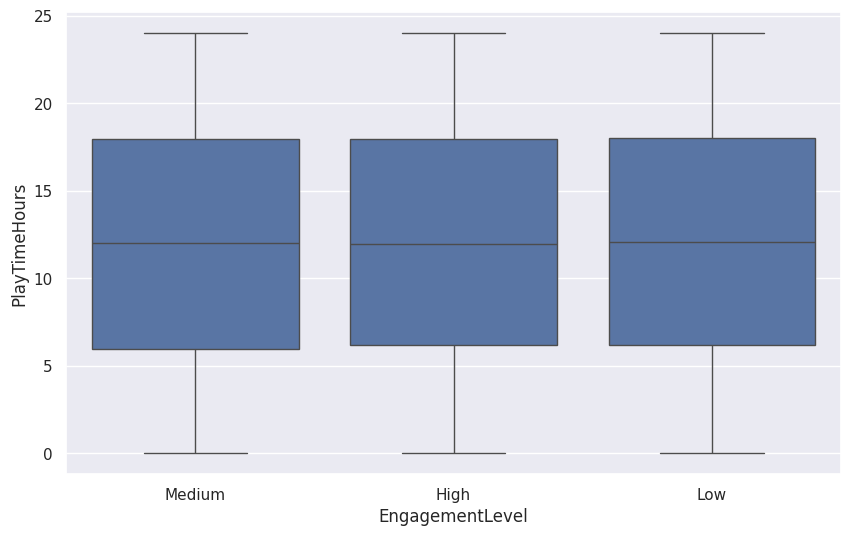

In [29]:
sns.boxplot(data=df, x='EngagementLevel', y='PlayTimeHours')

### 2.3 Statistiques descriptives

Calculez les statistiques de base (moyenne, médiane, écart-type, min, max) pour les variables numériques.  
Identifiez d'éventuels **outliers** visuellement.

       SessionsPerWeek  AvgSessionDurationMinutes   PlayerLevel  \
count     40034.000000               40034.000000  40034.000000   
mean          9.471774                  94.792252     49.655568   
std           5.763667                  49.011375     28.588379   
min           0.000000                  10.000000      1.000000   
25%           4.000000                  52.000000     25.000000   
50%           9.000000                  95.000000     49.000000   
75%          14.000000                 137.000000     74.000000   
max          19.000000                 179.000000     99.000000   

       AchievementsUnlocked  PlayTimeHours  
count          40034.000000   40034.000000  
mean              24.526477      12.024365  
std               14.430726       6.914638  
min                0.000000       0.000115  
25%               12.000000       6.067501  
50%               25.000000      12.008002  
75%               37.000000      17.963831  
max               49.000000      23.

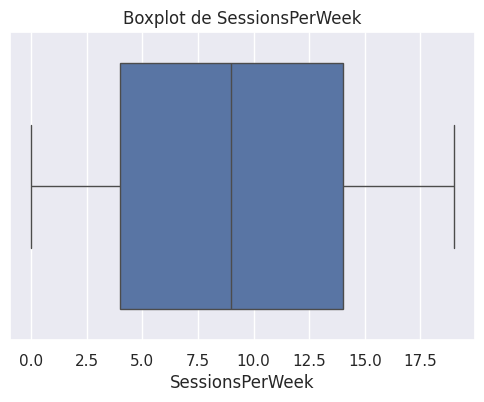

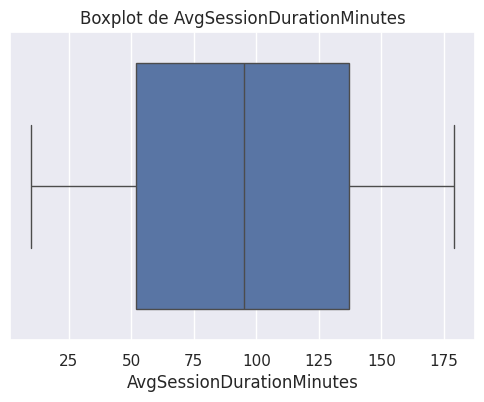

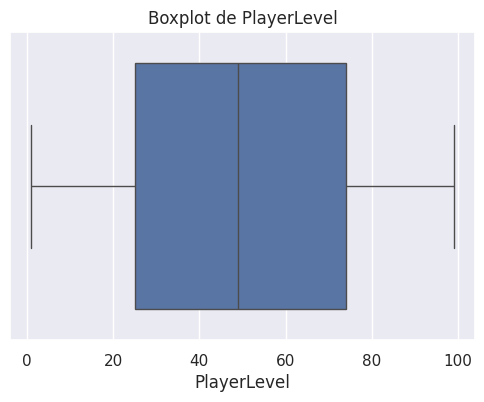

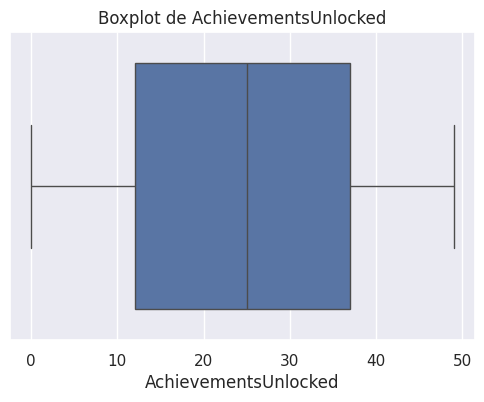

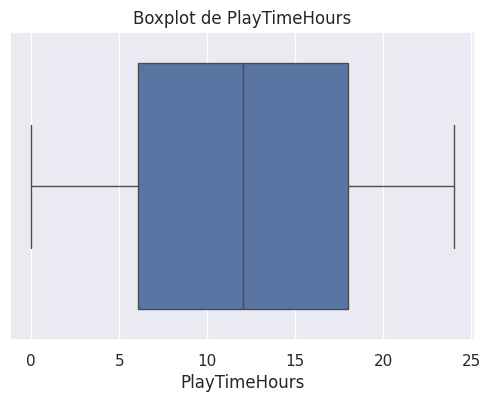

In [40]:
# TODO : Statistiques descriptives avec .describe()
num_cols = ['SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'PlayTimeHours']
print(df[num_cols].describe())

# TODO : Pour chaque variable numérique clé, tracez un boxplot pour visualiser les outliers
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot de {col}')
    plt.show()

### 2.4 Distribution de la variable cible

Visualisez la distribution de `PlayTimeHours`.  

> Un modèle linéaire fonctionne mieux si Y suit une distribution **proche de la normale**. Vérifiez cela.

Skewness : -0.002224638614477428


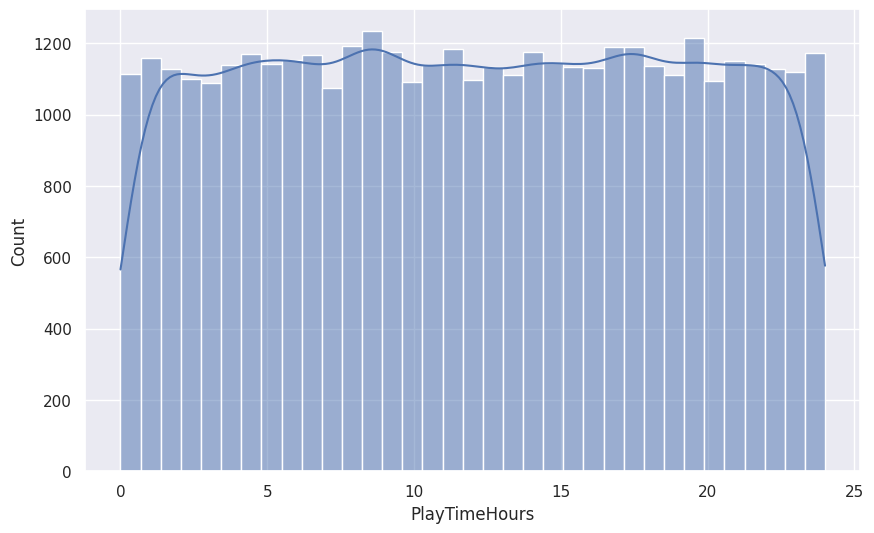

In [31]:
# TODO : Histogramme de PlayTimeHours avec courbe KDE (seaborn)
sns.histplot(data=df, x='PlayTimeHours', kde=True)
# TODO : Calculez la skewness (asymétrie) : df['PlayTimeHours'].skew()
skewness = df['PlayTimeHours'].skew()
print(f"Skewness : {skewness}")
# TODO : Commentez en markdown ce que vous observez

**Votre observation :**  
_..._

### 2.5 Analyse de corrélation — Le Scatter Plot

on commence par un **Scatter Plot** pour vérifier visuellement si une tendance linéaire existe entre les candidats X et Y.

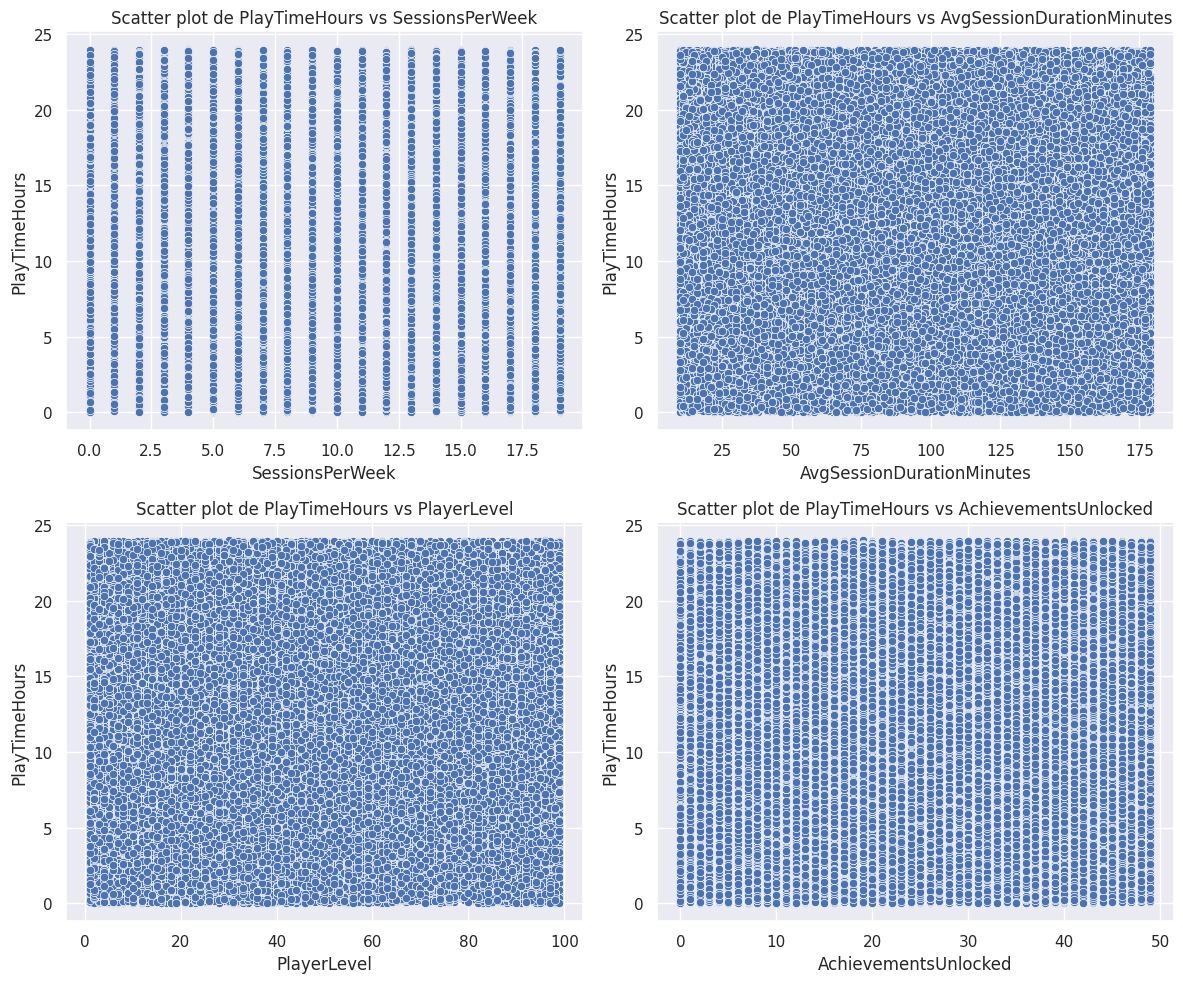

In [32]:
# TODO : Tracez 4 scatter plots (subplots 2x2) :
#   - SessionsPerWeek vs PlayTimeHours
#   - AvgSessionDurationMinutes vs PlayTimeHours
#   - PlayerLevel vs PlayTimeHours
#   - AchievementsUnlocked vs PlayTimeHours
# Ajoutez un titre et des labels d'axes clairs


x_variables_for_scatter = ['SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for i, col in enumerate(x_variables_for_scatter):
  sns.scatterplot(data=df, x=col, y='PlayTimeHours', ax=axes[i])

  axes[i].set_title(f'Scatter plot de PlayTimeHours vs {col}')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('PlayTimeHours')

plt.tight_layout()
plt.show()

,PlayTimeHours
PlayTimeHours,1.000000
AchievementsUnlocked,0.003913
AvgSessionDurationMinutes,-0.001925
SessionsPerWeek,-0.003655
PlayerLevel,-0.005152


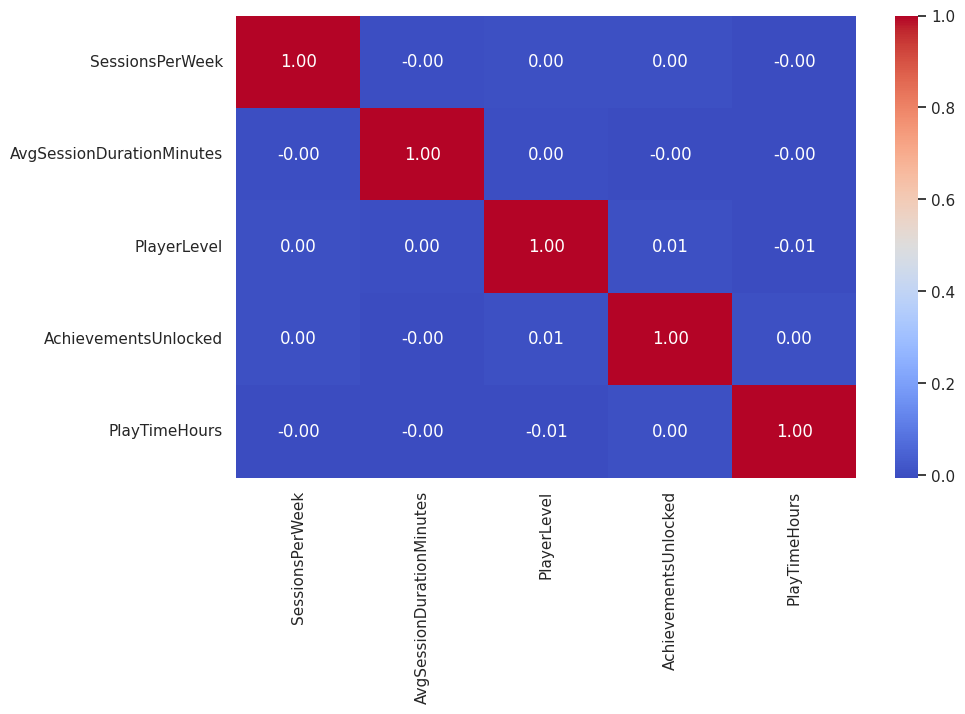

In [33]:
# TODO : Matrice de corrélation (heatmap seaborn) pour toutes les variables numériques
# Paramètre utile : annot=True, fmt='.2f, cmap='coolwarm'
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
# TODO : Identifiez la variable la plus corrélée avec PlayTimeHours
# Indice : df.corr()['PlayTimeHours'].sort_values(ascending=False)
df[num_cols].corr()['PlayTimeHours'].sort_values(ascending=False)

**Analyse :**  
- Variable la plus corrélée avec `PlayTimeHours` : _..._  
- Valeur de corrélation : _..._  
- Y a-t-il un risque de multicolinéarité entre les X ? _..._

### 2.6 Exploration des variables catégorielles

Comprenez la distribution des variables catégorielles disponibles dans le dataset.

Gender : 2 valeurs uniques
Gender
Male      23959
Female    16075
Name: count, dtype: int64
Location : 4 valeurs uniques
Location
USA       16000
Europe    12004
Asia       8095
Other      3935
Name: count, dtype: int64
GameGenre : 5 valeurs uniques
GameGenre
Sports        8048
Action        8039
Strategy      8012
Simulation    7983
RPG           7952
Name: count, dtype: int64
GameDifficulty : 3 valeurs uniques
GameDifficulty
Easy      20015
Medium    12011
Hard       8008
Name: count, dtype: int64
EngagementLevel : 3 valeurs uniques
EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64


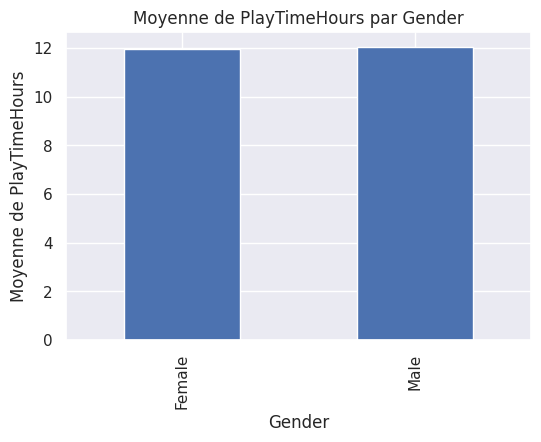

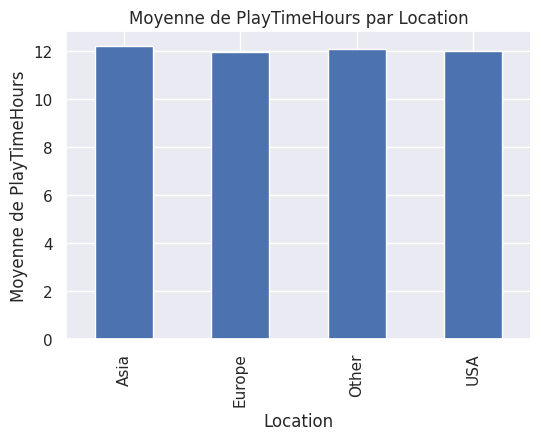

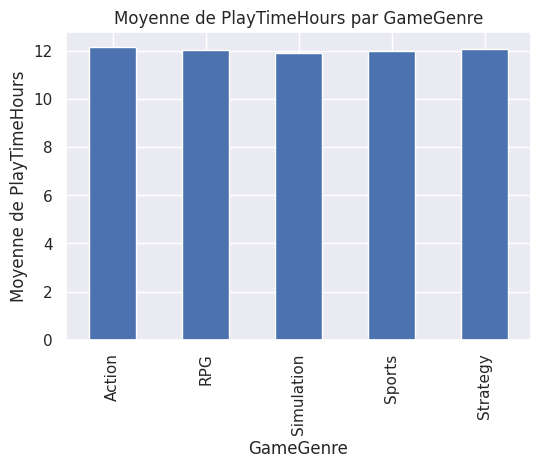

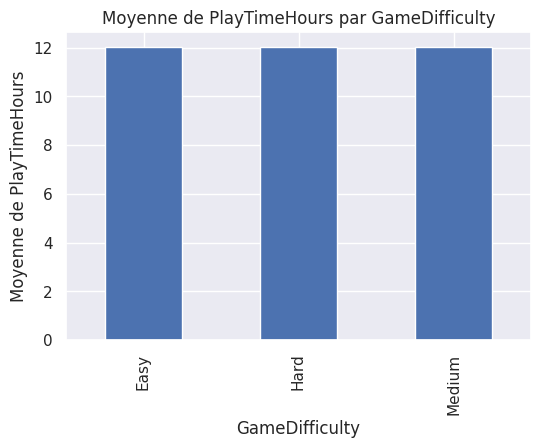

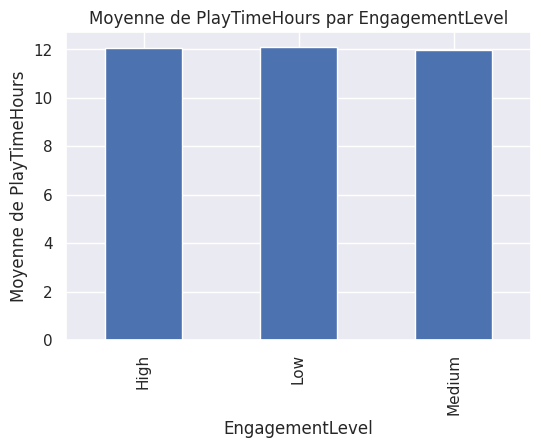

In [39]:
# TODO : Pour chaque colonne catégorielle (Gender, Location, GameGenre, GameDifficulty...)
#   - Affichez le nombre de valeurs uniques et leur fréquence (.value_counts())
#   - Tracez un barplot de la moyenne de PlayTimeHours par catégorie
#     (indice : df.groupby('Gender')['PlayTimeHours'].mean().plot(kind='bar'))

for col in cat_cols:
    print(f"{col} : {df[col].nunique()} valeurs uniques")
    print(df[col].value_counts())

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    df.groupby(col)['PlayTimeHours'].mean().plot(kind='bar')
    plt.title(f'Moyenne de PlayTimeHours par {col}')
    plt.xlabel(col)
    plt.ylabel('Moyenne de PlayTimeHours')
    plt.show()

# TODO : Quelle catégorie semble avoir le plus d'impact sur PlayTimeHours ?